In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuration pour les graphiques
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Chemin vers les fichiers CSV IMDB_SMALL
data_path = 'csv/imdb-small'  # Relatif car le notebook est dans le dossier data/

# Liste des fichiers à charger
files = [
    'movies.csv', 'persons.csv', 'characters.csv', 'directors.csv',
    'genres.csv', 'principals.csv', 'ratings.csv', 'titles.csv', 'writers.csv'
]

data = {}

print("Chargement des données...")
for file in files:
    name = file.split('.')[0]
    file_path = os.path.join(data_path, file)
    if os.path.exists(file_path):
        # On utilise low_memory=False pour éviter les warnings sur les types mixtes
        data[name] = pd.read_csv(file_path, low_memory=False)
        print(f"{name} chargé ({data[name].shape[0]} lignes)")
    else:
        print(f"Fichier non trouvé : {file_path}")


# Clean up the column names by removing the tuple format
for name, df in data.items():
    df.columns = [col.strip("(),'\"") for col in df.columns]

Chargement des données...
movies chargé (36859 lignes)
persons chargé (145847 lignes)
characters chargé (152898 lignes)
directors chargé (40933 lignes)
genres chargé (85426 lignes)
principals chargé (361863 lignes)
ratings chargé (36859 lignes)
titles chargé (775705 lignes)
writers chargé (82857 lignes)


In [14]:
def analyze_dataframe(df_name, df):
    print(f"\n{'='*20} ANALYSE : {df_name.upper()} {'='*20}")

    # 1. Dimensions
    print(f"Dimensions : {df.shape}")

    # 2. Types de données et valeurs manquantes
    info = pd.DataFrame({
        'Type': df.dtypes,
        'Valeurs Manquantes': df.isnull().sum(),
        '% Manquant': (df.isnull().sum() / len(df)) * 100,
        'Valeurs Uniques': df.nunique()
    })
    print("\n--- Structure et Qualité ---")
    print(info)

    # 3. Aperçu des premières lignes
    print("\n--- Aperçu ---")
    display(df.head(3))

# Exécuter l'analyse sur tous les fichiers chargés
for name, df in data.items():
    analyze_dataframe(name, df)


==================== ANALYSE : MOVIES ====================
Dimensions : (36859, 8)

--- Structure et Qualité ---
                   Type  Valeurs Manquantes  % Manquant  Valeurs Uniques
mid              object                   0    0.000000            36859
titleType        object                   0    0.000000                1
primaryTitle     object                   0    0.000000            34406
originalTitle    object                   0    0.000000            35206
isAdult           int64                   0    0.000000                1
startYear         int64                   0    0.000000              111
endYear         float64               36859  100.000000                0
runtimeMinutes  float64                  40    0.108522              223

--- Aperçu ---


,mid,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes
0,tt0002130,movie,Dante's Inferno,L'Inferno,0,1911,NaN,71.0
1,tt0002844,movie,Fantômas: In the Shadow of the Guillotine,Fantômas - À l'ombre de la guillotine,0,1913,NaN,54.0
2,tt0003014,movie,Ingeborg Holm,Ingeborg Holm,0,1913,NaN,96.0



==================== ANALYSE : PERSONS ====================
Dimensions : (145847, 4)

--- Structure et Qualité ---
                Type  Valeurs Manquantes  % Manquant  Valeurs Uniques
pid           object                   0    0.000000           145847
primaryName   object                   0    0.000000           143706
birthYear    float64               80311   55.065240              286
deathYear    float64              123826   84.901301              231

--- Aperçu ---


,pid,primaryName,birthYear,deathYear
0,nm0000001,Fred Astaire,1899.0,1987.0
1,nm0000002,Lauren Bacall,1924.0,2014.0
2,nm0000003,Brigitte Bardot,1934.0,NaN



==================== ANALYSE : CHARACTERS ====================
Dimensions : (152898, 3)

--- Structure et Qualité ---
        Type  Valeurs Manquantes  % Manquant  Valeurs Uniques
mid   object                   0         0.0            36649
pid   object                   0         0.0            59864
name  object                   0         0.0            98511

--- Aperçu ---


...

,mid,averageRating,numVotes
0,tt0002130,7.0,2794
1,tt0002844,6.9,2217
2,tt0003014,7.0,1193



==================== ANALYSE : TITLES ====================
Dimensions : (775705, 8)

--- Structure et Qualité ---
                   Type  Valeurs Manquantes  % Manquant  Valeurs Uniques
mid              object                   0    0.000000            36859
ordering          int64                   0    0.000000              149
title            object                   0    0.000000           481760
region           object               42118    5.429641              155
language         object              599095   77.232324               77
types            object              133290   17.183079               22
attributes       object              736103   94.894709               96
isOriginalTitle   int64                   0    0.000000                2

--- Aperçu ---


,mid,ordering,title,region,language,types,attributes,isOriginalTitle
0,tt0002130,10,Helvetti,FI,NaN,imdbDisplay,NaN,0
1,tt0002130,11,A pokol,HU,NaN,imdbDisplay,NaN,0
2,tt0002130,12,L'Inferno,IT,NaN,imdbDisplay,NaN,0



==================== ANALYSE : WRITERS ====================
Dimensions : (82857, 2)

--- Structure et Qualité ---
       Type  Valeurs Manquantes  % Manquant  Valeurs Uniques
mid  object                   0         0.0            35988
pid  object                   0         0.0            38841

--- Aperçu ---


,mid,pid
0,tt0002130,nm0019604
1,tt0002844,nm0019855
2,tt0002844,nm0275421


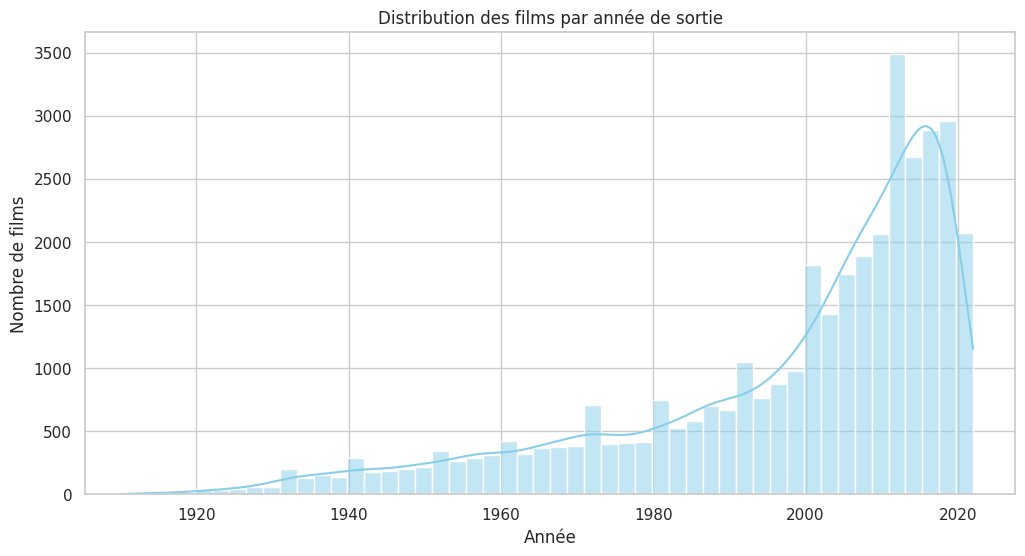

In [15]:
# A. Distribution des films par année

# Conversion de l'année en numérique (gestion des erreurs)
movies = data['movies'].copy()
movies['startYear'] = pd.to_numeric(movies['startYear'], errors='coerce')

plt.figure(figsize=(12, 6))
sns.histplot(data=movies, x='startYear', bins=50, kde=True, color='skyblue')
plt.title('Distribution des films par année de sortie')
plt.xlabel('Année')
plt.ylabel('Nombre de films')
plt.show()

/tmp/ipykernel_31472/1800859303.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')


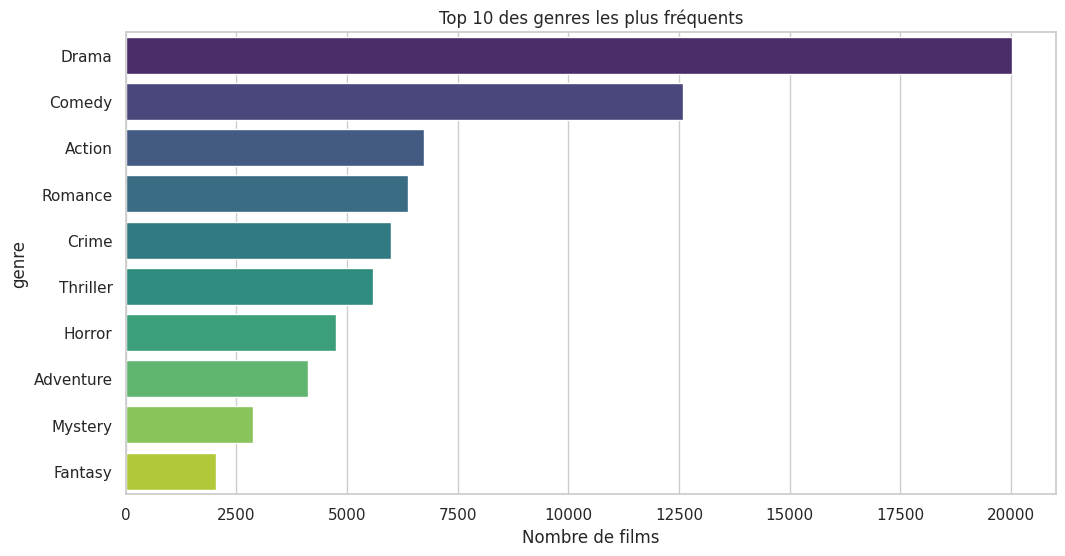

In [21]:
# B. Top 10 des genres les plus fréquents

genres = data['genres']

plt.figure(figsize=(12, 6))
top_genres = genres['genre'].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
plt.title('Top 10 des genres les plus fréquents')
plt.xlabel('Nombre de films')
plt.show()

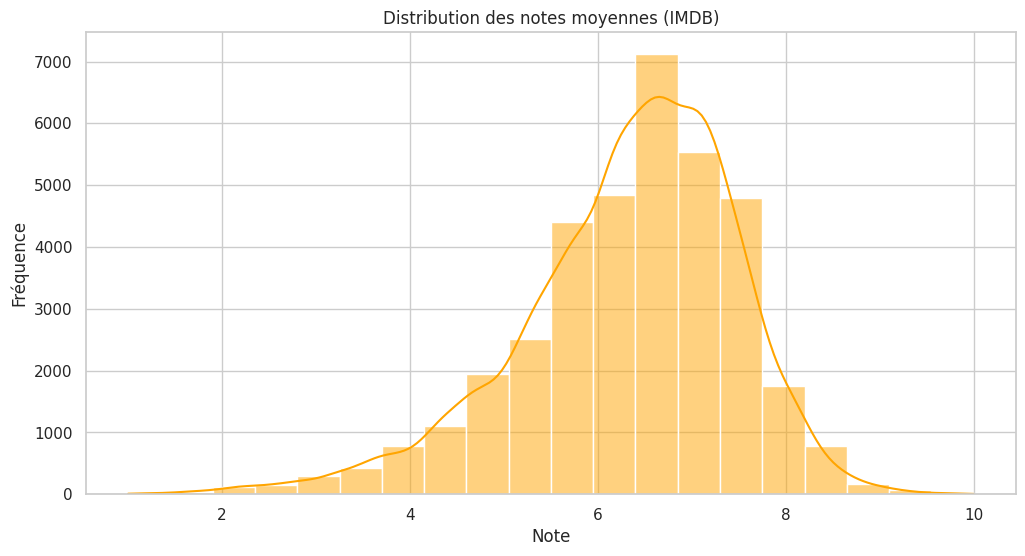

In [22]:
# C. Distribution des notes (Ratings)

ratings = data['ratings']

plt.figure(figsize=(12, 6))
sns.histplot(data=ratings, x='averageRating', bins=20, kde=True, color='orange')
plt.title('Distribution des notes moyennes (IMDB)')
plt.xlabel('Note')
plt.ylabel('Fréquence')
plt.show()

Nombre moyen de personnes crédités par film : 9.82


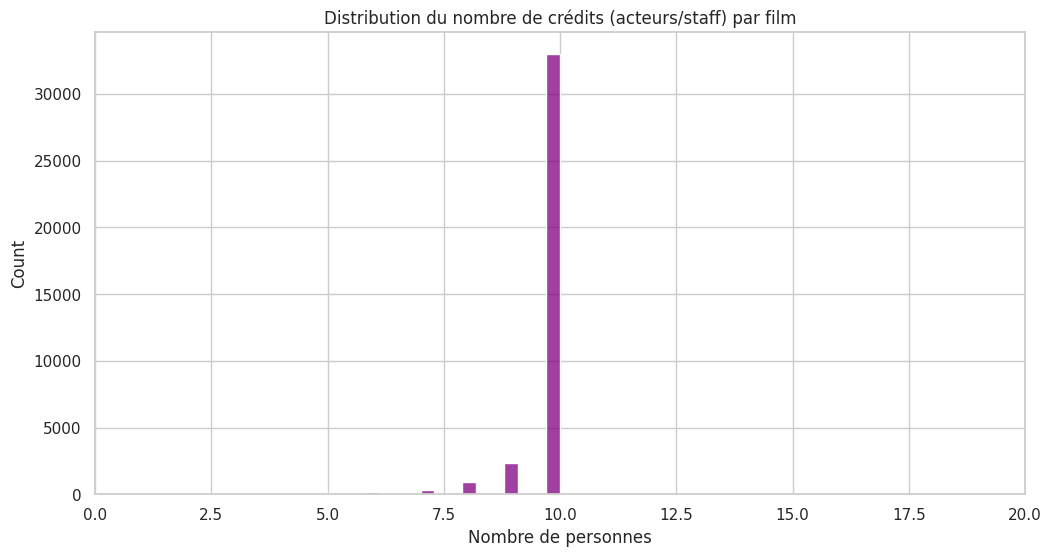

In [25]:
# D. Nombre moyen d’acteurs par film

# Correction : on utilise 'mid' au lieu de 'tconst'
principals = data['principals']

# On compte le nombre de lignes par mid
actors_per_movie = principals.groupby('mid').size()

mean_actors = actors_per_movie.mean()
print(f"Nombre moyen de personnes crédités par film : {mean_actors:.2f}")

plt.figure(figsize=(12, 6))
sns.histplot(actors_per_movie, bins=30, color='purple')
plt.title('Distribution du nombre de crédits (acteurs/staff) par film')
plt.xlabel('Nombre de personnes')
plt.xlim(0, 20)
plt.show()

In [27]:
# Relations et Intégrité

def check_orphan_keys(child_df, child_col, parent_df, parent_col, name_relation):
    parent_ids = set(parent_df[parent_col])
    child_ids = set(child_df[child_col])

    orphans = child_ids - parent_ids
    orphan_count = len(orphans)

    print(f"Relation {name_relation} :")
    if orphan_count == 0:
        print(" Intégrité respectée.")
    else:
        print(f" {orphan_count} orphelins trouvés ({orphan_count/len(child_df):.2%}).")

print("\n--- Vérification des Clés Étrangères (Corrigé) ---")

# Ratings -> Movies
check_orphan_keys(data['ratings'], 'mid', data['movies'], 'mid', 'Ratings -> Movies')

# Genres -> Movies
check_orphan_keys(data['genres'], 'mid', data['movies'], 'mid', 'Genres -> Movies')

# Principals -> Movies
check_orphan_keys(data['principals'], 'mid', data['movies'], 'mid', 'Principals -> Movies')

# Principals -> Persons (Attention, ici c'est pid)
check_orphan_keys(data['principals'], 'pid', data['persons'], 'pid', 'Principals -> Persons')

# Directors -> Persons
check_orphan_keys(data['directors'], 'pid', data['persons'], 'pid', 'Directors -> Persons')


--- Vérification des Clés Étrangères (Corrigé) ---
Relation Ratings -> Movies :
 Intégrité respectée.
Relation Genres -> Movies :
 Intégrité respectée.
Relation Principals -> Movies :
 Intégrité respectée.
Relation Principals -> Persons :
 5 orphelins trouvés (0.00%).
Relation Directors -> Persons :
 Intégrité respectée.
